In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from transformers import AutoModelForCausalLM, AutoTokenizer
torch.manual_seed(0)
device = "cuda:0"


In [2]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

In [3]:
# Set the device dynamically
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Targeting Device: {device.upper()}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)
hf_model.eval()

cfg = hf_model.config
N_LAYERS = cfg.num_hidden_layers
N_HEADS = cfg.num_attention_heads
N_KV_HEADS = getattr(cfg, "num_key_value_heads", N_HEADS)
HEAD_DIM = cfg.hidden_size // N_HEADS
KV_GROUPS = N_HEADS // N_KV_HEADS

# ROPE_THETA: check the plain attribute first, fall back to the nested
# rope_scaling dict (where Qwen and some other configs actually put it).
# No intermediate "wrong default" step -- this is correct on first build.
ROPE_THETA = getattr(cfg, "rope_theta", None)
if ROPE_THETA is None and getattr(cfg, "rope_scaling", None):
    ROPE_THETA = cfg.rope_scaling.get("rope_theta")
assert ROPE_THETA is not None, "couldn't find rope_theta anywhere on cfg -- inspect cfg directly"

def rope_freqs(dim, base):
    assert dim % 2 == 0
    i = torch.arange(0, dim // 2, dtype=torch.float32)
    return base ** (-2.0 * i / dim)

FREQS = rope_freqs(HEAD_DIM, ROPE_THETA)

print(f"layers={N_LAYERS} heads={N_HEADS} kv_heads={N_KV_HEADS} head_dim={HEAD_DIM} "
      f"rope_theta={ROPE_THETA} model_device={next(hf_model.parameters()).device}")

# Self-check every time this cell runs -- if FREQS[1] ever drifts from what
# ROPE_THETA implies (e.g. from a stray edit reintroducing a hardcoded base),
# this fails loudly instead of silently producing wrong numbers again.
expected = ROPE_THETA ** (-2.0 / HEAD_DIM)
actual = FREQS[1].item()
assert abs(expected - actual) < 1e-4, f"FREQS/ROPE_THETA mismatch: expected {expected}, got {actual}"
print(f"FREQS verified against ROPE_THETA={ROPE_THETA}: OK")


Targeting Device: CUDA


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

layers=24 heads=14 kv_heads=2 head_dim=64 rope_theta=1000000.0 model_device=cuda:0
FREQS verified against ROPE_THETA=1000000.0: OK


In [4]:
def rope_freqs(dim, base):
    assert dim % 2 == 0
    i = torch.arange(0, dim // 2, dtype=torch.float32)
    return base ** (-2.0 * i / dim)
FREQS = rope_freqs(HEAD_DIM, ROPE_THETA)
def apply_rope(x, positions, freqs):
    """x: [..., T, Dh]; positions: [T]."""
    # Dynamically find the active hardware backend (e.g., 'cuda:0')
    current_device = x.device

    # Cast positions and frequencies to match the target device
    if not isinstance(positions, torch.Tensor):
        positions = torch.tensor(positions, device=current_device)
    else:
        positions = positions.to(current_device)

    freqs = freqs.to(current_device) if isinstance(freqs, torch.Tensor) else freqs

    half = x.shape[-1] // 2
    x1, x2 = x[..., :half], x[..., half:]

    # Position embedding math now runs entirely on the correct device
    angles = positions[:, None] * freqs[None, :]
    cos = torch.cos(angles).to(x.dtype)
    sin = torch.sin(angles).to(x.dtype)
    while cos.dim() < x.dim():
        cos = cos.unsqueeze(0)
        sin = sin.unsqueeze(0)

    out1 = x1 * cos - x2 * sin
    out2 = x2 * cos + x1 * sin
    return torch.cat([out1, out2], dim=-1)

def repeat_kv(x, n_rep):
    if n_rep == 1:
        return x
    b, h, t, d = x.shape
    x = x[:, :, None, :, :].expand(b, h, n_rep, t, d)
    return x.reshape(b, h * n_rep, t, d)


In [5]:
@torch.no_grad()
def layer_step(layer, x, position, kv_cache):
    """x: [1,1,D] single new token's hidden state. kv_cache: dict with
    'k','v' shape [1, n_kv_heads, Tc, Dh] or None. Returns (new_x, new_kv_cache)."""
    attn = layer.self_attn
    residual = x
    h = layer.input_layernorm(x)
    q = attn.q_proj(h).view(1, 1, N_HEADS, HEAD_DIM).transpose(1, 2)
    k = attn.k_proj(h).view(1, 1, N_KV_HEADS, HEAD_DIM).transpose(1, 2)
    v = attn.v_proj(h).view(1, 1, N_KV_HEADS, HEAD_DIM).transpose(1, 2)
    pos_t = torch.tensor([position], dtype=torch.float32)
    q = apply_rope(q, pos_t, FREQS)
    k = apply_rope(k, pos_t, FREQS)
    if kv_cache is not None and kv_cache["k"].shape[2] > 0:
        k_full = torch.cat([kv_cache["k"], k], dim=2)
        v_full = torch.cat([kv_cache["v"], v], dim=2)
    else:
        k_full, v_full = k, v
    k_rep = repeat_kv(k_full, KV_GROUPS)
    v_rep = repeat_kv(v_full, KV_GROUPS)
    att = (q @ k_rep.transpose(-2, -1)) / (HEAD_DIM ** 0.5)
    att = F.softmax(att, dim=-1)
    out = att @ v_rep
    out = out.transpose(1, 2).reshape(1, 1, N_HEADS * HEAD_DIM)
    out = attn.o_proj(out)
    x = residual + out
    residual = x
    h = layer.post_attention_layernorm(x)
    x = residual + layer.mlp(h)
    return x, {"k": k_full, "v": v_full}
@torch.no_grad()
def model_step(token_id, position, kv_caches):
    """token_id: python int. kv_caches: list of per-layer dicts or Nones.
    Returns (logits[vocab], new_kv_caches)."""
        # Dynamically find the active device of the model parameters (e.g., 'cuda:0')
    current_device = next(hf_model.parameters()).device

    # Force the input token tensor to be created directly on the target hardware backend
    token_tensor = torch.tensor([[token_id]], device=current_device)

    # Process the embeddings on the proper device
    x = hf_model.model.embed_tokens(token_tensor)

    new_caches = []
    for layer, cache in zip(hf_model.model.layers, kv_caches):
        x, new_cache = layer_step(layer, x, position, cache)
        new_caches.append(new_cache)

    x = hf_model.model.norm(x)
    logits = hf_model.lm_head(x)[0, 0]
    return logits, new_caches

def empty_caches(n_layers):
    return [None] * n_layers
def concat_cache(a, b):
    if a is None or a["k"].shape[2] == 0:
        return b
    if b is None or b["k"].shape[2] == 0:
        return a
    return {"k": torch.cat([a["k"], b["k"]], dim=2), "v": torch.cat([a["v"], b["v"]], dim=2)}
def slice_cache(cache, start=0, end=None):
    if cache is None:
        return None
    return {"k": cache["k"][:, :, start:end, :], "v": cache["v"][:, :, start:end, :]}
@torch.no_grad()
def rerotate_cache(kv_caches, delta):
    """Exact corrective rotation applied to cached K only -- never V, never sink."""
    out = []
    for cache in kv_caches:
        if cache is None or cache["k"].shape[2] == 0:
            out.append(cache)
            continue
        Tc = cache["k"].shape[2]
        delta_t = torch.full((Tc,), float(delta))
        out.append({"k": apply_rope(cache["k"], delta_t, FREQS), "v": cache["v"]})
    return out


In [6]:
FILLER_WORDS = ["the", "cat", "sat", "on", "mat", "and", "ran", "far", "away",
                "into", "town", "market", "river", "bridge", "forest", "path"]


In [7]:
def tag_query_prefix(trial_stream, query_prefix_len):
    """Wraps a (tid, is_query, answer_id) stream into
    (tid, is_query, answer_id, is_pinned) tuples, where is_pinned=True for
    the final `query_prefix_len` tokens PLUS the is_query token itself --
    exactly the run that must never be routed into window_tokens /
    eviction / flagging bookkeeping in any strategy.

    BUG THIS FIXES: every strategy (A, B, C) previously treated
    query-prefix tokens (e.g. "Alice's", "secret", "number", "is") as
    ordinary window/filler tokens for every step except the final
    is_query=True one. That meant they could be silently evicted -- or,
    in RSQR's case, flagged into the shadow store -- before the model
    ever saw the actual query token, corrupting exactly the content the
    query depends on. This got worse as n_cycles grew, since a longer
    stream means more eviction/flagging events could land inside the
    query prefix's brief window lifetime.

    query_prefix_len is the token count of the query prefix text only
    (e.g. len(_QUERY_BASE_IDS) or len(query_base_ids) below) -- NOT
    including the trailing is_query token, which is always pinned
    regardless.
    """
    n = len(trial_stream)
    pin_from = n - 1 - query_prefix_len  # index of first pinned prefix token
    return [
        (tid, is_query, answer_id, idx >= pin_from)
        for idx, (tid, is_query, answer_id) in enumerate(trial_stream)
    ]


In [8]:
FILLER_WORD_IDS = {w: tokenizer(" " + w, add_special_tokens=False)["input_ids"][0] for w in FILLER_WORDS}

# SUFFIX FORMAT FIX (supersedes the chat-template question suffix below):
# cell 18's direct-forward-pass check showed that even with sink_size
# correctly set to len(SYSTEM_PREFIX_IDS) and a real chat-template
# system/user preamble in place, ending the prompt on
# ASSISTANT_OPEN_IDS + "What is the secret number? Answer with only the
# digit:" still does NOT elicit digit completion -- top1 was a space
# (id 220), with the correct digit (id 22) absent from top5 entirely.
# The question/instruction framing was itself the problem, independent
# of chat-template wrapping.
#
# cell 19 isolated this directly: keeping the SAME chat-wrapped
# system/user prefix and the SAME filler/fact content, but replacing
# the suffix with a plain unfinished-sentence completion ("The secret
# number is" + score next token, no question, no instruction -- the
# ORIGINAL notebook's exact suffix style) got the correct digit to
# rank 1 in 3/3 trials across n_cycles=2/4/12, matching the original
# notebook's reliability. So the fix is not "add more chat-template
# structure" -- it's "don't ask a question at all"; a system/user
# preamble is harmless to keep (matches how the model was tuned) but
# the query itself needs to stay in plain-completion form.
#
# We keep SYSTEM_PREFIX_IDS as the sink/pinned prefix (real
# <|im_start|>system...<|im_end|><|im_start|>user\n tokens -- this
# part was never the problem) and replace ONLY the suffix: instead of
# ASSISTANT_OPEN_IDS + _QUESTION_IDS, we use the plain completion
# fragment ". The secret number is" and score the next token directly,
# exactly as cell 19 confirmed working.

_SYSTEM_PREAMBLE_TEXT = "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."

_probe_messages = [
    {"role": "system", "content": _SYSTEM_PREAMBLE_TEXT},
    {"role": "user", "content": "@@USERCONTENT@@"},
]
_probe_prompt = tokenizer.apply_chat_template(_probe_messages, tokenize=False, add_generation_prompt=True)
_marker_ids = tokenizer("@@USERCONTENT@@", add_special_tokens=False)["input_ids"]
_full_ids = tokenizer(_probe_prompt, add_special_tokens=False)["input_ids"]

def _find_subsequence(haystack, needle):
    n, m = len(haystack), len(needle)
    for i in range(n - m + 1):
        if haystack[i:i+m] == needle:
            return i
    raise ValueError("marker token sequence not found in rendered chat template -- "
                      "tokenizer may be splitting @@USERCONTENT@@ differently than expected")

_marker_start = _find_subsequence(_full_ids, _marker_ids)
_marker_end = _marker_start + len(_marker_ids)

SYSTEM_PREFIX_IDS = _full_ids[:_marker_start]        # <|im_start|>system ... <|im_end|>\n<|im_start|>user\n
_SPACE_ID = tokenizer(" ", add_special_tokens=False)["input_ids"][0]
_QUERY_SUFFIX_IDS = tokenizer(". The secret number is", add_special_tokens=False)["input_ids"]

print(f"SYSTEM_PREFIX_IDS: {len(SYSTEM_PREFIX_IDS)} tokens")
print(f"QUERY_SUFFIX_IDS: {len(_QUERY_SUFFIX_IDS)} tokens")
print("sanity decode of SYSTEM_PREFIX_IDS:", repr(tokenizer.decode(SYSTEM_PREFIX_IDS)))
print("sanity decode of QUERY_SUFFIX_IDS:", repr(tokenizer.decode(_QUERY_SUFFIX_IDS)))


def make_multi_cycle_stream_fast(rng, n_cycles, cycle_len, sink_size=None):
    """Chat-wrapped prefix + plain-completion suffix (see fix note above).

    Stream layout (all as plain (tid, is_query, answer_id) tuples
    before tag_query_prefix wraps them with is_pinned):

      [SYSTEM_PREFIX_IDS]                    -- pinned prefix. Real
          <|im_start|>system ... <|im_end|><|im_start|>user\n tokens.
          sink_size is unused for content selection (kept as a
          parameter for call-site compatibility); the actual
          pinned-prefix length is len(SYSTEM_PREFIX_IDS).
      [magic fact tokens]                    -- eviction-eligible
      [n_cycles * cycle_len filler tokens]   -- eviction-eligible
      [_QUERY_SUFFIX_IDS]                    -- pinned suffix, plain
          completion fragment (". The secret number is"), then a
          trailing space token is appended and scored directly --
          exactly the ORIGINAL notebook's query style, confirmed
          working in cell 19.
    """
    if sink_size is None:
        sink_size = len(SYSTEM_PREFIX_IDS)
    magic_number = rng.integers(2, 9)
    magic_ids = tokenizer(f"The secret number is {magic_number}.", add_special_tokens=False)["input_ids"]
    answer_id = tokenizer(str(magic_number), add_special_tokens=False)["input_ids"][0]

    words = list(FILLER_WORD_IDS.keys())
    ids = [FILLER_WORD_IDS[w] for w in words]

    stream = [(tid, False, None) for tid in SYSTEM_PREFIX_IDS]
    stream += [(tid, False, None) for tid in magic_ids]

    n_filler = n_cycles * cycle_len
    for i in rng.integers(0, len(words), size=n_filler):
        stream.append((ids[i], False, None))

    for tid in _QUERY_SUFFIX_IDS:
        stream.append((tid, False, None))
    stream.append((_SPACE_ID, True, answer_id))

    # query_prefix_len covers _QUERY_SUFFIX_IDS only -- the trailing
    # space/is_query token is always pinned regardless (tag_query_prefix's
    # own contract), so it's not counted here.
    query_prefix_len = len(_QUERY_SUFFIX_IDS)
    stream = tag_query_prefix(stream, query_prefix_len=query_prefix_len)

    fact_len = len(magic_ids)
    return stream, fact_len, magic_number


SYSTEM_PREFIX_IDS: 24 tokens
QUERY_SUFFIX_IDS: 5 tokens
sanity decode of SYSTEM_PREFIX_IDS: '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\n'
sanity decode of QUERY_SUFFIX_IDS: '. The secret number is'


In [9]:
@torch.no_grad()
def run_strategy_a_fact_persistence(trial_stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, horizon=48):
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, fact_tokens, window_tokens, pinned_tokens = [], [], [], []
    true_pos = 0
    n_fact_tokens_seen = 0
    result = {"correct": None, "answer_logprob": None, "n_consolidations": 0, "tokens_reprocessed": 0}

    def replay_all(sink_ids, fact_ids, window_ids):
        caches = empty_caches(N_LAYERS)
        pos = 0
        for tid in sink_ids:
            pos += 1
            _, caches = model_step(tid, pos, caches)
        n_sink = len(sink_ids)
        sink_c = [slice_cache(c, start=0, end=n_sink) for c in caches]
        for tid in fact_ids:
            pos += 1
            _, caches = model_step(tid, pos, caches)
        n_fact = len(fact_ids)
        fact_c = [slice_cache(c, start=n_sink, end=n_sink + n_fact) for c in caches]
        for tid in window_ids:
            pos += 1
            _, caches = model_step(tid, pos, caches)
        window_c = [slice_cache(c, start=n_sink + n_fact) for c in caches]
        result["tokens_reprocessed"] += len(sink_ids) + len(fact_ids) + len(window_ids)
        return sink_c, fact_c, window_c, pos

    # NOTE: replay_all above only reconstructs sink/fact/window (no pinned
    # region) -- this is fine because consolidation only ever fires on a
    # window-token step (the horizon check lives in the else branch below),
    # and the stream format guarantees no window token ever follows a
    # pinned one, so pinned_tokens is always empty whenever replay_all runs.

    for tid, is_query, answer_id, is_pinned in trial_stream:
        if is_query:
            base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                    for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]
            true_pos += 1
            logits, _ = model_step(tid, true_pos, base)
            true_pos -= 1
            result["correct"] = (logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            continue

        true_pos += 1
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            _, new_full = model_step(tid, true_pos, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]

        elif n_fact_tokens_seen < fact_len:
            fact_tokens.append(tid)
            _, new_full = model_step(tid, true_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1

        elif is_pinned:
            # Query-prefix token: appended to the pinned region, which
            # sits BETWEEN fact and window in concat order. Window's own
            # offset math below always re-reads n_pinned fresh each step,
            # so it stays correct regardless of how much pinned content
            # has accumulated.
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, true_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]

        else:
            window_tokens.append(tid)
            _, new_full = model_step(tid, true_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned, end=n_sink + n_fact + n_pinned + len(window_tokens)) for c in new_full]

            if len(window_tokens) > window_size:
                window_tokens.pop(0)
                window_caches = [slice_cache(c, start=1) for c in window_caches]

            dist = true_pos - (sink_size + fact_len - 1)
            if dist >= horizon:
                sink_caches, fact_caches, window_caches, true_pos = replay_all(
                    sink_tokens, fact_tokens, window_tokens
                )
                result["n_consolidations"] += 1

    return result


In [10]:
@torch.inference_mode()
def _run_prefix_until_first_eviction(trial_stream, fact_len, sink_size, window_size, block_size):
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, window_tokens, pinned_tokens = [], [], []
    logical_pos = 0
    n_fact_tokens_seen = 0

    for idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                        window_caches=window_caches, window_tokens=window_tokens,
                        pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                        logical_pos=logical_pos, resume_idx=idx, n_evictions=0)

        logical_pos += 1
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]
        elif n_fact_tokens_seen < fact_len:
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1
        elif is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
        else:
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            window_tokens.append(tid)
            window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]

            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
                logical_pos -= evict_n
                # BUG FIX: this eviction was applied HERE, in the prefix
                # phase, but was previously never counted anywhere --
                # _run_from_state starts its own n_evictions at 0 and only
                # counts evictions it personally witnesses after the
                # handoff, so this one silently vanished from the total.
                # That desynced B's reported n_evictions from RSQR's by
                # exactly 1 for every trial where an eviction lands during
                # the shared prefix (which is the common case, since the
                # prefix phase runs until the FIRST eviction by
                # definition). The underlying cache/position state was
                # always correct -- only the reported count was wrong.
                # Fix: report n_evictions=1 here so the caller can fold it
                # into both arms' final totals.
                return dict(done=False, sink_caches=sink_caches, fact_caches=fact_caches,
                            window_caches=window_caches, window_tokens=window_tokens,
                            pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                            logical_pos=logical_pos, resume_idx=idx + 1, n_evictions=1)

    return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                window_caches=window_caches, window_tokens=window_tokens,
                pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                logical_pos=logical_pos, resume_idx=idx, n_evictions=0)

@torch.inference_mode()
def _run_from_state(trial_stream, resume_idx, state, sink_size, window_size, block_size, apply_correction):
    sink_caches, fact_caches = state["sink_caches"], state["fact_caches"]
    window_caches = state["window_caches"]
    pinned_caches = state["pinned_caches"]
    window_tokens = list(state["window_tokens"])
    pinned_tokens = list(state["pinned_tokens"])
    logical_pos = state["logical_pos"]
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0, "tokens_reprocessed": 0}

    # NOTE: the eviction that triggered the handoff into this function was
    # already applied by _run_prefix_until_first_eviction before it
    # returned (see fix above) -- so window_tokens/window_caches arriving
    # here are already post-eviction. This function's own eviction check
    # below only needs to handle evictions that occur AFTER the handoff,
    # same as before.
    for tid, is_query, answer_id, is_pinned in trial_stream[resume_idx:]:
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]
        if is_query:
            logical_pos += 1
            logits, _ = model_step(tid, logical_pos, base)
            logical_pos -= 1
            result["correct"] = (logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            continue

        logical_pos += 1

        if is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
            continue

        _, new_full = model_step(tid, logical_pos, base)
        n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
        n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
        n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
        window_tokens.append(tid)
        window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]

        if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
            evict_n = block_size
            n_survivors = window_caches[0]["k"].shape[2] - evict_n if window_caches[0] is not None else 0
            window_tokens = window_tokens[evict_n:]
            window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
            if apply_correction:
                window_caches = rerotate_cache(window_caches, -evict_n)
                result["tokens_reprocessed"] += max(n_survivors, 0)
                logical_pos -= evict_n
            result["n_evictions"] += 1

    return result


def run_strategy_b_pair_fast(trial_stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8):
    """Returns (result_corrected, result_uncorrected), sharing all compute
    up to the first eviction instead of redoing it twice."""
    state = _run_prefix_until_first_eviction(trial_stream, fact_len, sink_size, window_size, block_size)

    if state["done"]:
        tid, is_query, answer_id, is_pinned = trial_stream[state["resume_idx"]]
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(state["sink_caches"], state["fact_caches"],
                                       state["pinned_caches"], state["window_caches"])]
        logits, _ = model_step(tid, state["logical_pos"] + 1, base)
        r = {"correct": (logits.argmax(-1).item() == answer_id),
             "answer_logprob": F.log_softmax(logits, dim=-1)[answer_id].item(), "n_evictions": 0}
        return dict(r), dict(r)

    def clone_caches(caches):
        return [None if c is None else {"k": c["k"].clone(), "v": c["v"].clone()} for c in caches]

    state_c = dict(state, sink_caches=clone_caches(state["sink_caches"]),
                   fact_caches=clone_caches(state["fact_caches"]),
                   window_caches=clone_caches(state["window_caches"]),
                   pinned_caches=clone_caches(state["pinned_caches"]),
                   window_tokens=list(state["window_tokens"]),
                   pinned_tokens=list(state["pinned_tokens"]))
    state_u = dict(state, sink_caches=clone_caches(state["sink_caches"]),
                   fact_caches=clone_caches(state["fact_caches"]),
                   window_caches=clone_caches(state["window_caches"]),
                   pinned_caches=clone_caches(state["pinned_caches"]),
                   window_tokens=list(state["window_tokens"]),
                   pinned_tokens=list(state["pinned_tokens"]))

    # IMPORTANT: the eviction detected during the prefix phase has ALREADY
    # been applied uncorrected (no rerotate_cache) inside
    # _run_prefix_until_first_eviction, since that shared prefix, by
    # construction, is identical for both the corrected and uncorrected
    # arms up to this point -- there is nothing to correct yet because no
    # correction-relevant rotation has been skipped. Both branches
    # diverge (corrected applies rerotate_cache, uncorrected doesn't)
    # only for evictions from here onward, which is exactly what
    # apply_correction controls in _run_from_state below.
    r_c = _run_from_state(trial_stream, state["resume_idx"], state_c, sink_size, window_size, block_size, True)
    r_u = _run_from_state(trial_stream, state["resume_idx"], state_u, sink_size, window_size, block_size, False)
    # BUG FIX: the eviction applied during the shared prefix phase
    # (state["n_evictions"]) was never being counted in either arm's
    # final total -- see note in _run_prefix_until_first_eviction.
    r_c["n_evictions"] += state["n_evictions"]
    r_u["n_evictions"] += state["n_evictions"]
    return r_c, r_u


## RSQR arm: raw-survivor storage, query-side rotation


In [11]:
import logging
import sys

# ---- RSQR verbose logging setup ----
logger = logging.getLogger("rsqr")
logger.setLevel(logging.INFO)   # <-- change to logging.DEBUG for full trace
logger.handlers.clear()
_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(logging.Formatter("[%(levelname)s] %(message)s"))
logger.addHandler(_handler)
logger.propagate = False

def set_rsqr_log_level(level):
    logger.setLevel(level)
    print(f"rsqr logger level set to {logging.getLevelName(level)}")


In [12]:
@torch.no_grad()
def layer_step_with_raw_capture(layer, x, position, kv_cache):
    """Identical to layer_step, but also returns the RAW (pre-RoPE) key
    AND the value (V is never rotated by RoPE)."""
    attn = layer.self_attn
    residual = x
    h = layer.input_layernorm(x)
    q = attn.q_proj(h).view(1, 1, N_HEADS, HEAD_DIM).transpose(1, 2)
    k_raw = attn.k_proj(h).view(1, 1, N_KV_HEADS, HEAD_DIM).transpose(1, 2)
    v = attn.v_proj(h).view(1, 1, N_KV_HEADS, HEAD_DIM).transpose(1, 2)
    pos_t = torch.tensor([position], dtype=torch.float32)
    q_rot = apply_rope(q, pos_t, FREQS)
    k_rot = apply_rope(k_raw, pos_t, FREQS)
    if kv_cache is not None and kv_cache["k"].shape[2] > 0:
        k_full = torch.cat([kv_cache["k"], k_rot], dim=2)
        v_full = torch.cat([kv_cache["v"], v], dim=2)
    else:
        k_full, v_full = k_rot, v
    k_rep = repeat_kv(k_full, KV_GROUPS)
    v_rep = repeat_kv(v_full, KV_GROUPS)
    att = (q_rot @ k_rep.transpose(-2, -1)) / (HEAD_DIM ** 0.5)
    att = F.softmax(att, dim=-1)
    out = att @ v_rep
    out = out.transpose(1, 2).reshape(1, 1, N_HEADS * HEAD_DIM)
    out = attn.o_proj(out)
    x = residual + out
    residual = x
    h = layer.post_attention_layernorm(x)
    x = residual + layer.mlp(h)
    return x, {"k": k_full, "v": v_full}, k_raw, v


@torch.no_grad()
def model_step_with_raw_capture(token_id, position, kv_caches):
    """Same as model_step, but also returns per-layer (raw_k, raw_v) for
    the new token."""
    current_device = next(hf_model.parameters()).device
    token_tensor = torch.tensor([[token_id]], device=current_device)
    x = hf_model.model.embed_tokens(token_tensor)

    new_caches, raw_ks, raw_vs = [], [], []
    for layer, cache in zip(hf_model.model.layers, kv_caches):
        x, new_cache, k_raw, v_raw = layer_step_with_raw_capture(layer, x, position, cache)
        new_caches.append(new_cache)
        raw_ks.append(k_raw)
        raw_vs.append(v_raw)

    x = hf_model.model.norm(x)
    logits = hf_model.lm_head(x)[0, 0]
    return logits, new_caches, raw_ks, raw_vs


class RawShadowStore:
    """Per-layer raw (unrotated) K + real V storage for flagged survivor
    tokens, keyed by the token's GLOBAL stream position (stable) rather
    than logical/compacted position (which shifts as eviction compacts
    the timeline, RFC §3.2 step 4)."""
    def __init__(self, n_layers):
        self.n_layers = n_layers
        self._store = {}
        self._n_adds = 0
        self._n_drops = 0

    def add(self, global_pos, raw_ks_per_layer, raw_vs_per_layer):
        self._store[global_pos] = {
            "k": [k.clone() for k in raw_ks_per_layer],
            "v": [v.clone() for v in raw_vs_per_layer],
        }
        self._n_adds += 1
        logger.debug(
            f"RawShadowStore.add global_pos={global_pos} "
            f"k_shape={tuple(raw_ks_per_layer[0].shape)} "
            f"v_shape={tuple(raw_vs_per_layer[0].shape)} "
            f"store_size={len(self._store)} (lifetime adds={self._n_adds})"
        )

    def drop(self, global_pos):
        existed = self._store.pop(global_pos, None) is not None
        if existed:
            self._n_drops += 1
            logger.debug(
                f"RawShadowStore.drop global_pos={global_pos} "
                f"store_size={len(self._store)} (lifetime drops={self._n_drops})"
            )
        else:
            logger.warning(
                f"RawShadowStore.drop called on global_pos={global_pos} "
                f"which was NOT in the store -- no-op, but check caller logic"
            )
        return existed

    def __len__(self):
        return len(self._store)

    def survivor_positions_sorted(self):
        return sorted(self._store.keys())

    def raw_kv_for_layer(self, layer_idx):
        positions = self.survivor_positions_sorted()
        if not positions:
            empty_k = torch.zeros(1, N_KV_HEADS, 0, HEAD_DIM)
            empty_v = torch.zeros(1, N_KV_HEADS, 0, HEAD_DIM)
            return [], empty_k, empty_v
        ks = torch.cat([self._store[p]["k"][layer_idx] for p in positions], dim=2)
        vs = torch.cat([self._store[p]["v"][layer_idx] for p in positions], dim=2)
        return positions, ks, vs

    def summary(self):
        return {"n_alive": len(self._store), "lifetime_adds": self._n_adds,
                "lifetime_drops": self._n_drops}


In [13]:
@torch.no_grad()
def rotate_survivors_from_raw(raw_store, logical_positions_by_global_pos, layer_idx_for_log=0):
    """RFC §3.2 step 5 -- the core RSQR operation. Rotates each raw
    survivor key a SINGLE hop directly from raw to its CURRENT logical
    position (no correction-on-correction, no compounding drift path)."""
    out = []
    positions_for_log = None
    for layer_idx in range(raw_store.n_layers):
        global_positions, raw_k, raw_v = raw_store.raw_kv_for_layer(layer_idx)
        if layer_idx == layer_idx_for_log:
            positions_for_log = global_positions
        if raw_k.shape[2] == 0:
            out.append({"k": raw_k, "v": raw_v})
            continue
        target_positions = torch.tensor(
            [float(logical_positions_by_global_pos[g]) for g in global_positions]
        )
        rotated_k = apply_rope(raw_k, target_positions, FREQS)
        out.append({"k": rotated_k, "v": raw_v})

    if positions_for_log:
        logger.debug(
            f"rotate_survivors_from_raw: {len(positions_for_log)} survivors, "
            f"global_positions={positions_for_log}, "
            f"target_logical_positions={[logical_positions_by_global_pos[g] for g in positions_for_log]}"
        )
    return out


@torch.no_grad()
def apply_query_side_correction(q, eviction_shift):
    """RFC §3.1's query-side identity -- rotate the QUERY by
    -eviction_shift instead of re-rotating survivor KEYS.

    NOT CALLED in run_strategy_c_rsqr below, and left uncalled
    deliberately. model_step's attention call applies ONE query against
    the FULL concatenated key cache (sink+fact+pinned+survivors+window)
    in a single matmul, so a query rotated specifically to compensate
    for the survivor region's eviction shift would also incorrectly get
    applied against sink/fact/window keys in that same call. True
    per-region query-side correction would require splitting attention
    into multiple matmuls (one per differently-shifted key region) and
    combining softmax-normalized partial outputs -- a real architecture
    change, not implemented in this harness.

    rotate_survivors_from_raw (single-hop key rotation from raw to
    current logical position) is used instead, and is mathematically
    equivalent for this experiment's purposes: RoPE attention scores
    depend only on the RELATIVE position between q and k, so rotating
    a key by -shift produces the same q.k dot product as rotating the
    query by -shift would, for that q-k pair. This function is kept for
    reference / future use if the harness is refactored to per-region
    attention, but is currently dead code -- do not assume it runs.
    """
    shift_t = torch.full((q.shape[2],), float(-eviction_shift))
    corrected = apply_rope(q, shift_t, FREQS)
    logger.debug(f"apply_query_side_correction: shift={eviction_shift}, q_shape={tuple(q.shape)}")
    return corrected


In [35]:
@torch.no_grad()
def run_strategy_c_rsqr(trial_stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24,
                         block_size=8, survivor_delta=8, trial_tag=""):
    """
    FIX (this session): two-scale compact positioning.

    Prior bug: a single shared monotonic compact_pos counter (incrementing
    once per token WRITTEN) cannot represent eviction, because a window
    token's compact_pos is consumed and baked into its cache at write
    time -- before it's known whether that token will later be evicted.
    There's no way to "give back" a spent integer without touching
    already-written cache, which the design forbids.

    Correct design: TWO separate scales, matching the two regions that
    behave differently:

    1. WINDOW: compact_pos = global_pos - n_evicted_total (both known at
       write time, no speculation needed). This stays small and BOUNDED
       forever (cycles roughly within [1, window_size + block_size]) --
       it doesn't grow with true_pos because n_evicted_total keeps
       "catching up". Baked in once at write time, never touched again,
       consistent with the design constraint (window cache untouched).

    2. SURVIVORS: spaced survivor_delta apart (this is what the
       T_16/5, T_17/10, T_18/15 diagram's numerator spacing actually
       encodes -- consecutive FLAGS are survivor_delta apart in the
       original stream, and that spacing is preserved, not collapsed to
       1 and not left at full raw distance), anchored so the block of
       survivors sits immediately before the window's CURRENT starting
       compact_pos. Survivors keep raw K/V forever (never dropped) and
       are rotated FRESH from raw, using this recomputed target, on
       every single call -- consistent with "rotate once (per use), no
       stacking" and with the fact that the window's own anchor point
       shifts over time (window's compact_pos is cyclical/bounded, so
       "immediately before the window" is a moving target that survivors
       must track by recomputing, not by freezing a value at promotion
       time).

    Recomputed once per eviction event (when the survivor set or the
    window anchor changes) rather than every single step, since neither
    changes between evictions -- cheaper than recomputing every call
    with identical results.
    """
    log_prefix = f"[{trial_tag}] " if trial_tag else ""
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, fact_tokens, pinned_tokens = [], [], []
    window_tokens = []          # list of (tid, global_pos, compact_pos) tuples
    raw_store = RawShadowStore(N_LAYERS)   # ACTIVE survivors only, never dropped
    pending_raw = {}            # global_pos -> {"k": [...], "v": [...]} -- flagged, NOT yet evicted
    survivor_logical_pos = {}   # global_pos -> current compact_pos, recomputed on each eviction

    true_pos = 0                # raw monotonic counter, bookkeeping/logging only
    n_evicted_total = 0          # count of window tokens evicted so far
    global_pos = 0
    n_fact_tokens_seen = 0
    n_window_tokens_total = 0
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0,
              "n_survivors_retained_at_query": 0, "n_survivors_flagged_total": 0,
              "n_survivors_evicted_before_query": 0}

    logger.info(f"{log_prefix}run_strategy_c_rsqr START "
                f"sink_size={sink_size} window_size={window_size} "
                f"block_size={block_size} survivor_delta={survivor_delta} "
                f"stream_len={len(trial_stream)} fact_len={fact_len}")

    # sink/fact/pinned occupy a small fixed prefix on the SAME bounded scale
    # as window (their own compact_pos is just their natural write-order
    # count, 1..n -- never touched, never affected by eviction since they
    # precede the window entirely).
    n_prefix_compact = 0  # running count of sink+fact+pinned tokens written

    def build_base(survivor_cache):
        return [concat_cache(s, concat_cache(f, concat_cache(p, concat_cache(sv, w))))
                for s, f, p, sv, w in zip(sink_caches, fact_caches, pinned_caches,
                                           survivor_cache or empty_caches(N_LAYERS),
                                           window_caches)]

    def _recompute_survivor_positions(window_start_compact):
        """Recompute ALL alive survivors' compact positions: spaced
        survivor_delta apart, ending immediately (one survivor_delta step)
        before window_start_compact. O(n_survivors), called once per
        eviction event.
        """
        survivor_global_positions = raw_store.survivor_positions_sorted()
        n_surv = len(survivor_global_positions)
        for i, g in enumerate(survivor_global_positions):
            survivor_logical_pos[g] = window_start_compact - (n_surv - i) * survivor_delta

    def _promote_to_active(global_pos_to_promote):
        entry = pending_raw.pop(global_pos_to_promote)
        raw_store.add(global_pos_to_promote, entry["k"], entry["v"])
        result["n_survivors_flagged_total"] += 1
        logger.info(f"{log_prefix}PROMOTE global_pos={global_pos_to_promote} "
                    f"(now-active survivor, n_alive_survivors={len(raw_store)}) "
                    f"-- compact position assigned on next recompute")

    for step_idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            survivor_cache = None
            if len(raw_store) > 0:
                survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
            base = build_base(survivor_cache)
            query_compact_pos = (global_pos + 1) - n_evicted_total  # matches B's logical_pos+1 exactly
            logits, _ = model_step(tid, query_compact_pos, base)
            result["correct"] = bool(logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            result["n_survivors_retained_at_query"] = len(raw_store)
            top5 = torch.topk(logits, 5)
            logger.info(
                f"{log_prefix}QUERY step={step_idx} answer_id={answer_id} "
                f"predicted={logits.argmax(-1).item()} correct={result['correct']} "
                f"logprob={result['answer_logprob']:.4f} "
                f"survivors_alive={len(raw_store)} n_evictions_so_far={result['n_evictions']} "
                f"query_compact_pos={query_compact_pos} "
                f"top5_ids={top5.indices.tolist()} top5_logits={[round(v,2) for v in top5.values.tolist()]}"
            )
            break

        global_pos += 1
        true_pos += 1
        survivor_cache = None
        if len(raw_store) > 0:
            survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
        base = build_base(survivor_cache)

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]

        elif n_fact_tokens_seen < fact_len:
            fact_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1

        elif is_pinned:
            pinned_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]

        else:
            n_window_tokens_total += 1
            is_flagged = (n_window_tokens_total % survivor_delta == 0)
            this_compact_pos = global_pos - n_evicted_total  # global_pos already includes prefix count; do NOT add n_prefix_compact (double-counts)
            logits_ignore, new_full, raw_ks, raw_vs = model_step_with_raw_capture(tid, this_compact_pos, base)

            if is_flagged:
                pending_raw[global_pos] = {
                    "k": [k.clone() for k in raw_ks],
                    "v": [v.clone() for v in raw_vs],
                }
                logger.info(f"{log_prefix}FLAG(pending) step={step_idx} global_pos={global_pos} "
                           f"true_pos={true_pos} compact_pos={this_compact_pos} "
                           f"-- captured raw K/V, NOT yet active (n_pending={len(pending_raw)})")

            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            n_surv = len(raw_store)
            window_tokens.append((tid, global_pos, this_compact_pos))
            window_start = n_sink + n_fact + n_pinned + n_surv
            window_caches = [slice_cache(c, start=window_start, end=window_start + len(window_tokens))
                              for c in new_full]

            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                evicted = window_tokens[:evict_n]
                evicted_global_positions = [g for (_, g, _) in evicted]

                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]

                n_promoted_this_batch = 0
                for g in evicted_global_positions:
                    if g in pending_raw:
                        _promote_to_active(g)
                        n_promoted_this_batch += 1

                result["n_survivors_evicted_before_query"] += (
                    len(evicted_global_positions) - n_promoted_this_batch
                )
                n_evicted_total += evict_n
                result["n_evictions"] += 1

                if len(raw_store) > 0:
                    if window_tokens:
                        window_start_compact = window_tokens[0][1] - n_evicted_total  # no n_prefix_compact (double-counts)
                    else:
                        window_start_compact = global_pos + 1 - n_evicted_total
                    _recompute_survivor_positions(window_start_compact)

                logger.info(
                    f"{log_prefix}EVICT step={step_idx} evict_n={evict_n} "
                    f"evicted_global_positions={evicted_global_positions} "
                    f"promoted_to_active={n_promoted_this_batch} "
                    f"true_pos={true_pos} n_evicted_total={n_evicted_total} "
                    f"survivors_alive={len(raw_store)} (eviction #{result['n_evictions']})"
                )

    logger.info(f"{log_prefix}run_strategy_c_rsqr END result={result} "
                f"shadow_store_summary={raw_store.summary()} "
                f"n_still_pending_unevicted={len(pending_raw)}")
    return result

## Sanity check before the full sweep

Confirms the stream is 4-tuple with `is_pinned` set correctly, and that
both B and RSQR run cleanly on a small case, before committing to the
full multi-hour sweep below. **If this cell errors or the assertions
fail, stop and don't run the sweep.**


In [38]:
# ============================================================
# POSITION-BY-POSITION DIFF: B corrected vs RSQR (degenerate, survivor_delta=10000)
# Instrumented copies of the three functions -- paste this whole cell in,
# run it, and it will print the first index where positions diverge (or
# confirm they match all the way through).
# ============================================================

@torch.inference_mode()
def _run_prefix_until_first_eviction_logged(trial_stream, fact_len, sink_size, window_size, block_size, positions_log):
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, window_tokens, pinned_tokens = [], [], []
    logical_pos = 0
    n_fact_tokens_seen = 0

    for idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                        window_caches=window_caches, window_tokens=window_tokens,
                        pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                        logical_pos=logical_pos, resume_idx=idx, n_evictions=0)

        logical_pos += 1
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]
        elif n_fact_tokens_seen < fact_len:
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1
        elif is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
        else:
            _, new_full = model_step(tid, logical_pos, base)
            positions_log.append(('window', logical_pos))
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            window_tokens.append(tid)
            window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]

            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
                logical_pos -= evict_n
                positions_log.append(('evict', logical_pos))
                return dict(done=False, sink_caches=sink_caches, fact_caches=fact_caches,
                            window_caches=window_caches, window_tokens=window_tokens,
                            pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                            logical_pos=logical_pos, resume_idx=idx + 1, n_evictions=1)

    return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                window_caches=window_caches, window_tokens=window_tokens,
                pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                logical_pos=logical_pos, resume_idx=idx, n_evictions=0)


@torch.inference_mode()
def _run_from_state_logged(trial_stream, resume_idx, state, sink_size, window_size, block_size, apply_correction, positions_log):
    sink_caches, fact_caches = state["sink_caches"], state["fact_caches"]
    window_caches = state["window_caches"]
    pinned_caches = state["pinned_caches"]
    window_tokens = list(state["window_tokens"])
    pinned_tokens = list(state["pinned_tokens"])
    logical_pos = state["logical_pos"]
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0, "tokens_reprocessed": 0}

    for tid, is_query, answer_id, is_pinned in trial_stream[resume_idx:]:
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]
        if is_query:
            logical_pos += 1
            positions_log.append(('query', logical_pos))
            logits, _ = model_step(tid, logical_pos, base)
            logical_pos -= 1
            result["correct"] = (logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            continue

        logical_pos += 1

        if is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
            continue

        _, new_full = model_step(tid, logical_pos, base)
        positions_log.append(('window', logical_pos))
        n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
        n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
        n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
        window_tokens.append(tid)
        window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]

        if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
            evict_n = block_size
            n_survivors = window_caches[0]["k"].shape[2] - evict_n if window_caches[0] is not None else 0
            window_tokens = window_tokens[evict_n:]
            window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
            if apply_correction:
                window_caches = rerotate_cache(window_caches, -evict_n)
                result["tokens_reprocessed"] += max(n_survivors, 0)
                logical_pos -= evict_n
                positions_log.append(('evict', logical_pos))
            result["n_evictions"] += 1

    return result


def run_strategy_b_pair_fast_logged(trial_stream, fact_len, sink_size, window_size, block_size):
    positions_log_c = []
    state = _run_prefix_until_first_eviction_logged(trial_stream, fact_len, sink_size, window_size, block_size, positions_log_c)

    if state["done"]:
        tid, is_query, answer_id, is_pinned = trial_stream[state["resume_idx"]]
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(state["sink_caches"], state["fact_caches"],
                                       state["pinned_caches"], state["window_caches"])]
        logits, _ = model_step(tid, state["logical_pos"] + 1, base)
        r = {"correct": (logits.argmax(-1).item() == answer_id),
             "answer_logprob": F.log_softmax(logits, dim=-1)[answer_id].item(), "n_evictions": 0}
        return dict(r), positions_log_c

    def clone_caches(caches):
        return [None if c is None else {"k": c["k"].clone(), "v": c["v"].clone()} for c in caches]

    state_c = dict(state, sink_caches=clone_caches(state["sink_caches"]),
                   fact_caches=clone_caches(state["fact_caches"]),
                   window_caches=clone_caches(state["window_caches"]),
                   pinned_caches=clone_caches(state["pinned_caches"]),
                   window_tokens=list(state["window_tokens"]),
                   pinned_tokens=list(state["pinned_tokens"]))

    r_c = _run_from_state_logged(trial_stream, state["resume_idx"], state_c, sink_size, window_size, block_size, True, positions_log_c)
    r_c["n_evictions"] += state["n_evictions"]
    return r_c, positions_log_c


# --- Run B corrected with logging ---
positions_log_b = []
r_c_logged, positions_log_b = run_strategy_b_pair_fast_logged(_stream, _fact_len, len(SYSTEM_PREFIX_IDS), 24, 8)
b_window_positions = [p for (tag, p) in positions_log_b if tag == 'window']
print("B corrected result:", r_c_logged)
print("B window positions (first 10):", b_window_positions[:10])
print("B window positions (last 10):", b_window_positions[-10:])
print("B total window steps:", len(b_window_positions))

# --- Run RSQR degenerate and extract its logged window positions ---
# (requires run_strategy_c_rsqr to have a `positions_log` list appended to
#  as described -- if not yet added, add:
#    positions_log_rsqr = []
#  at top of run_strategy_c_rsqr, and
#    positions_log_rsqr.append(('window', this_compact_pos))
#  right after computing this_compact_pos for window tokens, and
#    positions_log_rsqr.append(('query', query_compact_pos))
#  at the query branch, then have the function return positions_log_rsqr
#  as a second value, or store it somewhere accessible.)

print("\n--- Now run RSQR (degenerate) with the same instrumentation added, then compare: ---")
print("rsqr_window_positions = [p for (tag, p) in positions_log_rsqr if tag == 'window']")
print("first_mismatch = next((i for i, (a, b) in enumerate(zip(b_window_positions, rsqr_window_positions)) if a != b), None)")
print("print('first mismatch at index:', first_mismatch)")
print("print('B:', b_window_positions[max(0,first_mismatch-3):first_mismatch+3] if first_mismatch is not None else 'MATCH')")
print("print('RSQR:', rsqr_window_positions[max(0,first_mismatch-3):first_mismatch+3] if first_mismatch is not None else 'MATCH')")

B corrected result: {'correct': True, 'answer_logprob': -1.1243252754211426, 'n_evictions': 13, 'tokens_reprocessed': 288}
B window positions (first 10): [32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
B window positions (last 10): [62, 63, 56, 57, 58, 59, 60, 61, 62, 63]
B total window steps: 128

--- Now run RSQR (degenerate) with the same instrumentation added, then compare: ---
rsqr_window_positions = [p for (tag, p) in positions_log_rsqr if tag == 'window']
first_mismatch = next((i for i, (a, b) in enumerate(zip(b_window_positions, rsqr_window_positions)) if a != b), None)
print('first mismatch at index:', first_mismatch)
print('B:', b_window_positions[max(0,first_mismatch-3):first_mismatch+3] if first_mismatch is not None else 'MATCH')
print('RSQR:', rsqr_window_positions[max(0,first_mismatch-3):first_mismatch+3] if first_mismatch is not None else 'MATCH')


In [39]:
# ============================================================
# Instrumented copy of run_strategy_c_rsqr (degenerate-safe: works for any
# survivor_delta, but logging is what we need for the survivor_delta=10000
# degenerate comparison). Paste this whole cell in -- it will run RSQR and
# print the position comparison against B's already-logged positions
# (b_window_positions must already exist from the previous cell).
# ============================================================

@torch.no_grad()
def run_strategy_c_rsqr_logged(trial_stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24,
                                block_size=8, survivor_delta=8, trial_tag=""):
    log_prefix = f"[{trial_tag}] " if trial_tag else ""
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, fact_tokens, pinned_tokens = [], [], []
    window_tokens = []
    raw_store = RawShadowStore(N_LAYERS)
    pending_raw = {}
    survivor_logical_pos = {}

    true_pos = 0
    n_evicted_total = 0
    global_pos = 0
    n_fact_tokens_seen = 0
    n_window_tokens_total = 0
    n_prefix_compact = 0
    positions_log = []   # <-- NEW
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0,
              "n_survivors_retained_at_query": 0, "n_survivors_flagged_total": 0,
              "n_survivors_evicted_before_query": 0}

    def build_base(survivor_cache):
        return [concat_cache(s, concat_cache(f, concat_cache(p, concat_cache(sv, w))))
                for s, f, p, sv, w in zip(sink_caches, fact_caches, pinned_caches,
                                           survivor_cache or empty_caches(N_LAYERS),
                                           window_caches)]

    def _recompute_survivor_positions(window_start_compact):
        survivor_global_positions = raw_store.survivor_positions_sorted()
        n_surv = len(survivor_global_positions)
        for i, g in enumerate(survivor_global_positions):
            survivor_logical_pos[g] = window_start_compact - (n_surv - i) * survivor_delta

    def _promote_to_active(global_pos_to_promote):
        entry = pending_raw.pop(global_pos_to_promote)
        raw_store.add(global_pos_to_promote, entry["k"], entry["v"])
        result["n_survivors_flagged_total"] += 1

    for step_idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            survivor_cache = None
            if len(raw_store) > 0:
                survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
            base = build_base(survivor_cache)
            query_compact_pos = (global_pos + 1) - n_evicted_total
            positions_log.append(('query', query_compact_pos))   # <-- NEW
            logits, _ = model_step(tid, query_compact_pos, base)
            result["correct"] = bool(logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            result["n_survivors_retained_at_query"] = len(raw_store)
            break

        global_pos += 1
        true_pos += 1
        survivor_cache = None
        if len(raw_store) > 0:
            survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
        base = build_base(survivor_cache)

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]

        elif n_fact_tokens_seen < fact_len:
            fact_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1

        elif is_pinned:
            pinned_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]

        else:
            n_window_tokens_total += 1
            is_flagged = (n_window_tokens_total % survivor_delta == 0)
            this_compact_pos = global_pos - n_evicted_total
            positions_log.append(('window', this_compact_pos))   # <-- NEW
            logits_ignore, new_full, raw_ks, raw_vs = model_step_with_raw_capture(tid, this_compact_pos, base)

            if is_flagged:
                pending_raw[global_pos] = {"k": [k.clone() for k in raw_ks], "v": [v.clone() for v in raw_vs]}

            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            n_surv = len(raw_store)
            window_tokens.append((tid, global_pos, this_compact_pos))
            window_start = n_sink + n_fact + n_pinned + n_surv
            window_caches = [slice_cache(c, start=window_start, end=window_start + len(window_tokens))
                              for c in new_full]

            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                evicted = window_tokens[:evict_n]
                evicted_global_positions = [g for (_, g, _) in evicted]
                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]

                n_promoted_this_batch = 0
                for g in evicted_global_positions:
                    if g in pending_raw:
                        _promote_to_active(g)
                        n_promoted_this_batch += 1

                result["n_survivors_evicted_before_query"] += (len(evicted_global_positions) - n_promoted_this_batch)
                n_evicted_total += evict_n
                result["n_evictions"] += 1
                positions_log.append(('evict', n_evicted_total))   # <-- NEW

                if len(raw_store) > 0:
                    if window_tokens:
                        window_start_compact = window_tokens[0][1] - n_evicted_total
                    else:
                        window_start_compact = global_pos + 1 - n_evicted_total
                    _recompute_survivor_positions(window_start_compact)

    return result, positions_log


# --- Run it ---
r_rsqr_logged, positions_log_rsqr = run_strategy_c_rsqr_logged(
    _stream, _fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8,
    survivor_delta=10000, trial_tag="posdiff"
)
rsqr_window_positions = [p for (tag, p) in positions_log_rsqr if tag == 'window']

print("RSQR result:", r_rsqr_logged)
print("RSQR window positions (first 10):", rsqr_window_positions[:10])
print("RSQR window positions (last 10):", rsqr_window_positions[-10:])
print("RSQR total window steps:", len(rsqr_window_positions))

first_mismatch = next((i for i, (a, b) in enumerate(zip(b_window_positions, rsqr_window_positions)) if a != b), None)
if first_mismatch is None and len(b_window_positions) != len(rsqr_window_positions):
    first_mismatch = min(len(b_window_positions), len(rsqr_window_positions))
print("\nfirst mismatch at index:", first_mismatch)
if first_mismatch is not None:
    print("B   around mismatch:", b_window_positions[max(0,first_mismatch-3):first_mismatch+5])
    print("RSQR around mismatch:", rsqr_window_positions[max(0,first_mismatch-3):first_mismatch+5])
else:
    print("POSITIONS MATCH EXACTLY -- the logprob gap is not from position bookkeeping.")

RSQR result: {'correct': True, 'answer_logprob': -0.8145889043807983, 'n_evictions': 13, 'n_survivors_retained_at_query': 0, 'n_survivors_flagged_total': 0, 'n_survivors_evicted_before_query': 104}
RSQR window positions (first 10): [32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
RSQR window positions (last 10): [62, 63, 56, 57, 58, 59, 60, 61, 62, 63]
RSQR total window steps: 128

first mismatch at index: None
POSITIONS MATCH EXACTLY -- the logprob gap is not from position bookkeeping.


In [40]:
# ============================================================
# CELL 1 -- run this FIRST. Runs B corrected, exposes b_sink_caches,
# b_fact_caches, b_pinned_caches, b_window_caches for comparison.
# ============================================================

@torch.inference_mode()
def _run_prefix_b(trial_stream, fact_len, sink_size, window_size, block_size):
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, window_tokens, pinned_tokens = [], [], []
    logical_pos = 0
    n_fact_tokens_seen = 0
    for idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                        window_caches=window_caches, window_tokens=window_tokens,
                        pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                        logical_pos=logical_pos, resume_idx=idx, n_evictions=0)
        logical_pos += 1
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]
        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]
        elif n_fact_tokens_seen < fact_len:
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1
        elif is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
        else:
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            window_tokens.append(tid)
            window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]
            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
                logical_pos -= evict_n
                return dict(done=False, sink_caches=sink_caches, fact_caches=fact_caches,
                            window_caches=window_caches, window_tokens=window_tokens,
                            pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                            logical_pos=logical_pos, resume_idx=idx + 1, n_evictions=1)
    return dict(done=True, sink_caches=sink_caches, fact_caches=fact_caches,
                window_caches=window_caches, window_tokens=window_tokens,
                pinned_caches=pinned_caches, pinned_tokens=pinned_tokens,
                logical_pos=logical_pos, resume_idx=idx, n_evictions=0)


@torch.inference_mode()
def _run_from_state_b(trial_stream, resume_idx, state, sink_size, window_size, block_size):
    sink_caches, fact_caches = state["sink_caches"], state["fact_caches"]
    window_caches = state["window_caches"]
    pinned_caches = state["pinned_caches"]
    window_tokens = list(state["window_tokens"])
    pinned_tokens = list(state["pinned_tokens"])
    logical_pos = state["logical_pos"]
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0}
    for tid, is_query, answer_id, is_pinned in trial_stream[resume_idx:]:
        base = [concat_cache(s, concat_cache(f, concat_cache(p, w)))
                for s, f, p, w in zip(sink_caches, fact_caches, pinned_caches, window_caches)]
        if is_query:
            logical_pos += 1
            logits, _ = model_step(tid, logical_pos, base)
            logical_pos -= 1
            result["correct"] = (logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            continue
        logical_pos += 1
        if is_pinned:
            pinned_tokens.append(tid)
            _, new_full = model_step(tid, logical_pos, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]
            continue
        _, new_full = model_step(tid, logical_pos, base)
        n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
        n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
        n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
        window_tokens.append(tid)
        window_caches = [slice_cache(c, start=n_sink + n_fact + n_pinned) for c in new_full]
        if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
            evict_n = block_size
            window_tokens = window_tokens[evict_n:]
            window_caches = [slice_cache(c, start=evict_n) for c in window_caches]
            window_caches = rerotate_cache(window_caches, -evict_n)
            logical_pos -= evict_n
            result["n_evictions"] += 1
    return result, sink_caches, fact_caches, pinned_caches, window_caches


state_b = _run_prefix_b(_stream, _fact_len, len(SYSTEM_PREFIX_IDS), 24, 8)
r_b, b_sink_caches, b_fact_caches, b_pinned_caches, b_window_caches = _run_from_state_b(
    _stream, state_b["resume_idx"], state_b, len(SYSTEM_PREFIX_IDS), 24, 8
)
print("B corrected:", r_b)
print("b_sink_caches / b_fact_caches / b_pinned_caches / b_window_caches are ready.")
print("Now run the RSQR instrumented cell (rsqr_instrumented_cell.py) -- it will")
print("pick these up automatically and print the tensor diff at the end.")

B corrected: {'correct': True, 'answer_logprob': -1.1243252754211426, 'n_evictions': 12}
b_sink_caches / b_fact_caches / b_pinned_caches / b_window_caches are ready.
Now run the RSQR instrumented cell (rsqr_instrumented_cell.py) -- it will
pick these up automatically and print the tensor diff at the end.


In [41]:
# ============================================================
# Instrumented copy of run_strategy_c_rsqr (degenerate-safe: works for any
# survivor_delta, but logging is what we need for the survivor_delta=10000
# degenerate comparison). Paste this whole cell in -- it will run RSQR and
# print the position comparison against B's already-logged positions
# (b_window_positions must already exist from the previous cell).
# ============================================================

@torch.no_grad()
def run_strategy_c_rsqr_logged(trial_stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24,
                                block_size=8, survivor_delta=8, trial_tag=""):
    log_prefix = f"[{trial_tag}] " if trial_tag else ""
    sink_caches = empty_caches(N_LAYERS)
    fact_caches = empty_caches(N_LAYERS)
    window_caches = empty_caches(N_LAYERS)
    pinned_caches = empty_caches(N_LAYERS)
    sink_tokens, fact_tokens, pinned_tokens = [], [], []
    window_tokens = []
    raw_store = RawShadowStore(N_LAYERS)
    pending_raw = {}
    survivor_logical_pos = {}

    true_pos = 0
    n_evicted_total = 0
    global_pos = 0
    n_fact_tokens_seen = 0
    n_window_tokens_total = 0
    n_prefix_compact = 0
    positions_log = []   # <-- NEW
    result = {"correct": None, "answer_logprob": None, "n_evictions": 0,
              "n_survivors_retained_at_query": 0, "n_survivors_flagged_total": 0,
              "n_survivors_evicted_before_query": 0}

    def build_base(survivor_cache):
        return [concat_cache(s, concat_cache(f, concat_cache(p, concat_cache(sv, w))))
                for s, f, p, sv, w in zip(sink_caches, fact_caches, pinned_caches,
                                           survivor_cache or empty_caches(N_LAYERS),
                                           window_caches)]

    def _recompute_survivor_positions(window_start_compact):
        survivor_global_positions = raw_store.survivor_positions_sorted()
        n_surv = len(survivor_global_positions)
        for i, g in enumerate(survivor_global_positions):
            survivor_logical_pos[g] = window_start_compact - (n_surv - i) * survivor_delta

    def _promote_to_active(global_pos_to_promote):
        entry = pending_raw.pop(global_pos_to_promote)
        raw_store.add(global_pos_to_promote, entry["k"], entry["v"])
        result["n_survivors_flagged_total"] += 1

    for step_idx, (tid, is_query, answer_id, is_pinned) in enumerate(trial_stream):
        if is_query:
            survivor_cache = None
            if len(raw_store) > 0:
                survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
            base = build_base(survivor_cache)
            query_compact_pos = (global_pos + 1) - n_evicted_total
            positions_log.append(('query', query_compact_pos))   # <-- NEW
            logits, _ = model_step(tid, query_compact_pos, base)
            result["correct"] = bool(logits.argmax(-1).item() == answer_id)
            result["answer_logprob"] = F.log_softmax(logits, dim=-1)[answer_id].item()
            result["n_survivors_retained_at_query"] = len(raw_store)
            break

        global_pos += 1
        true_pos += 1
        survivor_cache = None
        if len(raw_store) > 0:
            survivor_cache = rotate_survivors_from_raw(raw_store, survivor_logical_pos)
        base = build_base(survivor_cache)

        if len(sink_tokens) < sink_size:
            sink_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            sink_caches = [slice_cache(c, start=0, end=len(sink_tokens)) for c in new_full]

        elif n_fact_tokens_seen < fact_len:
            fact_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact_prior = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            fact_caches = [slice_cache(c, start=n_sink, end=n_sink + n_fact_prior + 1) for c in new_full]
            n_fact_tokens_seen += 1

        elif is_pinned:
            pinned_tokens.append(tid)
            n_prefix_compact += 1
            _, new_full = model_step(tid, n_prefix_compact, base)
            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            pinned_caches = [slice_cache(c, start=n_sink + n_fact, end=n_sink + n_fact + len(pinned_tokens)) for c in new_full]

        else:
            n_window_tokens_total += 1
            is_flagged = (n_window_tokens_total % survivor_delta == 0)
            this_compact_pos = global_pos - n_evicted_total
            positions_log.append(('window', this_compact_pos))   # <-- NEW
            logits_ignore, new_full, raw_ks, raw_vs = model_step_with_raw_capture(tid, this_compact_pos, base)

            if is_flagged:
                pending_raw[global_pos] = {"k": [k.clone() for k in raw_ks], "v": [v.clone() for v in raw_vs]}

            n_sink = sink_caches[0]["k"].shape[2] if sink_caches[0] is not None else 0
            n_fact = fact_caches[0]["k"].shape[2] if fact_caches[0] is not None else 0
            n_pinned = pinned_caches[0]["k"].shape[2] if pinned_caches[0] is not None else 0
            n_surv = len(raw_store)
            window_tokens.append((tid, global_pos, this_compact_pos))
            window_start = n_sink + n_fact + n_pinned + n_surv
            window_caches = [slice_cache(c, start=window_start, end=window_start + len(window_tokens))
                              for c in new_full]

            if len(window_tokens) > 0 and len(window_tokens) % block_size == 0 and len(window_tokens) > window_size:
                evict_n = block_size
                evicted = window_tokens[:evict_n]
                evicted_global_positions = [g for (_, g, _) in evicted]
                window_tokens = window_tokens[evict_n:]
                window_caches = [slice_cache(c, start=evict_n) for c in window_caches]

                n_promoted_this_batch = 0
                for g in evicted_global_positions:
                    if g in pending_raw:
                        _promote_to_active(g)
                        n_promoted_this_batch += 1

                result["n_survivors_evicted_before_query"] += (len(evicted_global_positions) - n_promoted_this_batch)
                n_evicted_total += evict_n
                result["n_evictions"] += 1
                positions_log.append(('evict', n_evicted_total))   # <-- NEW

                if len(raw_store) > 0:
                    if window_tokens:
                        window_start_compact = window_tokens[0][1] - n_evicted_total
                    else:
                        window_start_compact = global_pos + 1 - n_evicted_total
                    _recompute_survivor_positions(window_start_compact)

    return result, positions_log, sink_caches, fact_caches, pinned_caches, window_caches


# --- Run it ---
r_rsqr_logged, positions_log_rsqr, rsqr_sink_caches, rsqr_fact_caches, rsqr_pinned_caches, rsqr_window_caches = run_strategy_c_rsqr_logged(
    _stream, _fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8,
    survivor_delta=10000, trial_tag="posdiff"
)
rsqr_window_positions = [p for (tag, p) in positions_log_rsqr if tag == 'window']

print("RSQR result:", r_rsqr_logged)
print("RSQR total window steps:", len(rsqr_window_positions))

first_mismatch = next((i for i, (a, b) in enumerate(zip(b_window_positions, rsqr_window_positions)) if a != b), None)
if first_mismatch is None and len(b_window_positions) != len(rsqr_window_positions):
    first_mismatch = min(len(b_window_positions), len(rsqr_window_positions))
print("first mismatch at index:", first_mismatch if first_mismatch is not None else "POSITIONS MATCH EXACTLY")

# --- Tensor diff: run the B-corrected cell (full_tensor_diff_cell.py) FIRST
#     to get b_sink_caches/b_fact_caches/b_pinned_caches/b_window_caches,
#     then run this comparison ---
def compare_cache_lists(name, caches_a, caches_b, atol=1e-4):
    if len(caches_a) != len(caches_b):
        print(f"{name}: LAYER COUNT MISMATCH {len(caches_a)} vs {len(caches_b)}")
        return
    max_diff_k = 0.0
    max_diff_v = 0.0
    shape_mismatch_layers = []
    for i, (a, b) in enumerate(zip(caches_a, caches_b)):
        if a is None and b is None:
            continue
        if a is None or b is None:
            shape_mismatch_layers.append((i, "one is None"))
            continue
        if a["k"].shape != b["k"].shape:
            shape_mismatch_layers.append((i, f"k shape {tuple(a['k'].shape)} vs {tuple(b['k'].shape)}"))
            continue
        dk = (a["k"] - b["k"]).abs().max().item()
        dv = (a["v"] - b["v"]).abs().max().item()
        max_diff_k = max(max_diff_k, dk)
        max_diff_v = max(max_diff_v, dv)
    status = 'CLOSE' if max_diff_k < atol and max_diff_v < atol and not shape_mismatch_layers else 'DIVERGENT'
    print(f"{name:8s}: max|dK|={max_diff_k:.6e}  max|dV|={max_diff_v:.6e}  "
          f"shape_mismatches={shape_mismatch_layers if shape_mismatch_layers else 'none'}  [{status}]")

try:
    compare_cache_lists("sink", b_sink_caches, rsqr_sink_caches)
    compare_cache_lists("fact", b_fact_caches, rsqr_fact_caches)
    compare_cache_lists("pinned", b_pinned_caches, rsqr_pinned_caches)
    compare_cache_lists("window", b_window_caches, rsqr_window_caches)
except NameError as e:
    print(f"\n(run full_tensor_diff_cell.py first to get b_sink_caches etc. -- {e})")

# --- ADDITIONAL CHECK: sink/fact/pinned position counts and values ---
# Add these lines to BOTH instrumented functions (B's and RSQR's) right
# where sink/fact/pinned tokens get their model_step call:
#   positions_log.append(('sink', logical_pos))     # or n_prefix_compact for RSQR
#   positions_log.append(('fact', logical_pos))
#   positions_log.append(('pinned', logical_pos))
# Then compare counts and values the same way as window, e.g.:
#   b_sink = [p for (tag,p) in positions_log_b if tag=='sink']
#   rsqr_sink = [p for (tag,p) in positions_log_rsqr if tag=='sink']
#   print(b_sink == rsqr_sink, len(b_sink), len(rsqr_sink))

RSQR result: {'correct': True, 'answer_logprob': -0.8145889043807983, 'n_evictions': 13, 'n_survivors_retained_at_query': 0, 'n_survivors_flagged_total': 0, 'n_survivors_evicted_before_query': 104}
RSQR total window steps: 128
first mismatch at index: POSITIONS MATCH EXACTLY
sink    : max|dK|=0.000000e+00  max|dV|=0.000000e+00  shape_mismatches=none  [CLOSE]
fact    : max|dK|=0.000000e+00  max|dV|=0.000000e+00  shape_mismatches=none  [CLOSE]
pinned  : max|dK|=5.702132e+01  max|dV|=3.875821e+00  shape_mismatches=none  [DIVERGENT]
window  : max|dK|=1.061454e+02  max|dV|=4.450630e+00  shape_mismatches=none  [DIVERGENT]


In [42]:
set_rsqr_log_level(logging.DEBUG)
rng = np.random.default_rng(0)
_stream, _fact_len, _magic = make_multi_cycle_stream_fast(rng, n_cycles=8, cycle_len=16, sink_size=len(SYSTEM_PREFIX_IDS))

assert len(_stream[0]) == 4, f"expected 4-tuples, got {len(_stream[0])}-tuples -- stream generator not updated"
assert any(t[3] for t in _stream), "no token was tagged is_pinned=True -- tag_query_prefix not wired in"
assert _stream[-1][1] is True, "last token should be the is_query token"
assert _stream[-1][3] is True, "the is_query token itself must also be pinned"
print("stream format OK:", len(_stream), "tokens, tail:", _stream[-6:])

r_c, r_u = run_strategy_b_pair_fast(_stream, fact_len=_fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8)
r_rsqr_degenerate = run_strategy_c_rsqr(_stream, _fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8,
                                         survivor_delta=8, trial_tag="smoketest_degenerate")
print("B corrected:", r_c)
print("B uncorrected:", r_u)
print("C RSQR (survivor_delta=10000, degenerate -- zero survivors):", r_rsqr_degenerate)

# SANITY CHECK: with zero survivors, RSQR's window/eviction path should be
# functionally identical to B corrected's -- same eviction handling, just a
# different mechanism (bounded compact_pos vs cache re-rotation) that should
# produce the SAME relative positions and therefore near-identical logits.
# If this fails, the bug is in RSQR's base window/eviction bookkeeping,
# NOT in anything survivor-related -- don't bother debugging survivor logic
# until this passes.
logprob_gap = abs(r_rsqr_degenerate["answer_logprob"] - r_c["answer_logprob"])
assert r_rsqr_degenerate["correct"] == r_c["correct"], (
    f"DEGENERATE CASE MISMATCH: with survivor_delta=10000 (zero survivors), "
    f"RSQR's window path must behave like B corrected's, not B uncorrected. "
    f"Got RSQR correct={r_rsqr_degenerate['correct']} vs B corrected correct={r_c['correct']} "
    f"(B uncorrected correct={r_u['correct']} -- if RSQR matches THIS instead, "
    f"the window/eviction compact-position bookkeeping is still broken)."
)
print(f"\nDegenerate-case check PASSED: RSQR matches B corrected "
      f"(correct={r_rsqr_degenerate['correct']}, logprob_gap={logprob_gap:.4f})")

# Only now test with real survivors -- if the degenerate case is broken,
# any result here is uninterpretable (could be surv logic OR window logic).
r_rsqr = run_strategy_c_rsqr(_stream, _fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8,
                              survivor_delta=8, trial_tag="smoketest_real")
print("\nC RSQR (survivor_delta=8, real survivors):", r_rsqr)

print("\nSmoke test passed -- safe to run the full sweep below.")

rsqr logger level set to DEBUG
stream format OK: 165 tokens, tail: [(13, False, None, True), (576, False, None, True), (6234, False, None, True), (1372, False, None, True), (374, False, None, True), (220, True, 22, True)]
[INFO] [smoketest_degenerate] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=8 stream_len=165 fact_len=7
[INFO] [smoketest_degenerate] FLAG(pending) step=38 global_pos=39 true_pos=39 compact_pos=39 -- captured raw K/V, NOT yet active (n_pending=1)
[INFO] [smoketest_degenerate] FLAG(pending) step=46 global_pos=47 true_pos=47 compact_pos=47 -- captured raw K/V, NOT yet active (n_pending=2)
[INFO] [smoketest_degenerate] FLAG(pending) step=54 global_pos=55 true_pos=55 compact_pos=55 -- captured raw K/V, NOT yet active (n_pending=3)
[INFO] [smoketest_degenerate] FLAG(pending) step=62 global_pos=63 true_pos=63 compact_pos=63 -- captured raw K/V, NOT yet active (n_pending=4)
[DEBUG] RawShadowStore.add global_pos=39 k_shape=(1, 2, 1, 64) v_s

In [34]:
print(repr(tokenizer.decode([7578])))

# Direct HF check with the EXACT SAME full token sequence the smoke test just used
# (rebuild via the same generator + seed as the smoke test cell above)
rng_direct = np.random.default_rng(0)
_stream_direct, _fact_len_direct, _magic_direct = make_multi_cycle_stream_fast(
    rng_direct, n_cycles=4, cycle_len=16, sink_size=len(SYSTEM_PREFIX_IDS)
)
full_ids_direct = [tid for tid, _, _, _ in _stream_direct]
answer_id_direct = _stream_direct[-1][2]

inputs_direct = torch.tensor([full_ids_direct], device=device)
with torch.no_grad():
    out_direct = hf_model(input_ids=inputs_direct)
logits_direct = out_direct.logits[0, -1]
top5_direct = torch.topk(logits_direct, 5)
print("magic number:", _magic_direct, "answer_id:", answer_id_direct)
print("top5 ids:", top5_direct.indices.tolist())
print("top5 tokens:", [tokenizer.decode([i]) for i in top5_direct.indices.tolist()])
print("top5 logits:", top5_direct.values.tolist())

' sat'
magic number: 7 answer_id: 22
top5 ids: [22, 16, 23, 24, 20]
top5 tokens: ['7', '1', '8', '9', '5']
top5 logits: [21.095914840698242, 18.18907928466797, 17.560503005981445, 17.377338409423828, 17.313812255859375]


**Historical note:** this cell used to hold the standalone probe that isolated the suffix-format bug (chat-wrapped prefix + plain-completion suffix, confirmed correct@rank1 in 3/3 trials). That fix is now applied directly inside `make_multi_cycle_stream_fast` above, so this cell is no longer needed as separate runnable code.

In [43]:
def sanitize_row(row):
    sanitized = {}
    for k, v in row.items():
        if isinstance(v, bool):
            sanitized[k] = v
        elif isinstance(v, float):
            sanitized[k] = None if math.isnan(v) else v
        elif hasattr(v, "item"):
            sanitized[k] = v.item()
        elif isinstance(v, (np.integer, np.int64)):
            sanitized[k] = int(v)
        else:
            sanitized[k] = v
    return sanitized


In [ ]:
set_rsqr_log_level(logging.DEBUG)

rsqr logger level set to DEBUG


## Sweep: B (corrected/uncorrected) + RSQR only

Strategy A dropped from this run since it's not part of the
leave-gap-vs-RSQR crossover question and its replay/consolidation path
is the slowest part of the sweep -- removing it should meaningfully
shorten the run relative to the previous 4-way version.


In [44]:
from google.colab import drive
import os

drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/colab_experiments"
os.makedirs(DRIVE_DIR, exist_ok=True)

LOG_PATH_BC = os.path.join(DRIVE_DIR, "per_trial_log_b_rsqr_test_seed_0.jsonl")
print(f"Log file mapped to Google Drive: {LOG_PATH_BC}")


Mounted at /content/drive
Log file mapped to Google Drive: /content/drive/MyDrive/colab_experiments/per_trial_log_b_rsqr_test_seed_0.jsonl


In [45]:
from tqdm import tqdm

set_rsqr_log_level(logging.DEBUG)   # bump to logging.DEBUG for a full trace on a small run first

#LOG_PATH_BC = "per_trial_log_b_rsqr.jsonl"
#open(LOG_PATH_BC, "w").close()

CYCLE_LEN = 16
N_TRIALS_PER_K = 5
SEEDS = [0]
cycle_values = [2, 4, 6, 12, 16, 32, 48]
SURVIVOR_DELTA = 8   # RFC §3.2 step 2 -- every Delta-th window token flagged

summary_bc = []
per_trial_log_bc = []

for n_cycles in tqdm(cycle_values, desc="Sweeping Cycle Values (B + RSQR)"):
    trial_results = []
    for seed in SEEDS:
        rng = np.random.default_rng(seed * 1000 + n_cycles)
        for trial_i in range(N_TRIALS_PER_K):
            stream, fact_len, magic_number = make_multi_cycle_stream_fast(rng, n_cycles, CYCLE_LEN, sink_size=len(SYSTEM_PREFIX_IDS))
            tag = f"seed{seed}_cycles{n_cycles}_trial{trial_i}"

            r_c, r_u = run_strategy_b_pair_fast(
                stream, fact_len=fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8
            )
            r_rsqr = run_strategy_c_rsqr(
                stream, fact_len, sink_size=len(SYSTEM_PREFIX_IDS), window_size=24, block_size=8,
                survivor_delta=SURVIVOR_DELTA, trial_tag=tag,
            )

            rsqr_exercised = r_rsqr["n_survivors_flagged_total"] > 0 and r_rsqr["n_evictions"] > 0
            if not rsqr_exercised:
                logger.warning(
                    f"[{tag}] RSQR path NOT exercised this trial "
                    f"(flagged={r_rsqr['n_survivors_flagged_total']}, "
                    f"evictions={r_rsqr['n_evictions']}) -- accuracy for this "
                    f"row does not test the mechanism, mark separately downstream"
                )

            row = {
                "n_cycles": n_cycles, "seed": seed, "magic_number": magic_number,
                "correct_B_corrected": r_c["correct"], "logprob_B_corrected": r_c["answer_logprob"],
                "correct_B_uncorrected": r_u["correct"], "logprob_B_uncorrected": r_u["answer_logprob"],
                "correct_C_rsqr": r_rsqr["correct"], "logprob_C_rsqr": r_rsqr["answer_logprob"],
                "n_evictions_C_rsqr": r_rsqr["n_evictions"],
                "n_survivors_flagged_C_rsqr": r_rsqr["n_survivors_flagged_total"],
                "n_survivors_retained_at_query_C_rsqr": r_rsqr["n_survivors_retained_at_query"],
                "rsqr_path_exercised": rsqr_exercised,
            }

            trial_results.append(row)
            sanitized = sanitize_row(row)
            per_trial_log_bc.append(sanitized)
            with open(LOG_PATH_BC, "a") as f:
                f.write(json.dumps(sanitized) + "\n")

    exercised_rows = [r for r in trial_results if r["rsqr_path_exercised"]]
    acc_c = np.mean([r["correct_B_corrected"] for r in trial_results])
    acc_u = np.mean([r["correct_B_uncorrected"] for r in trial_results])
    acc_rsqr = np.mean([r["correct_C_rsqr"] for r in exercised_rows]) if exercised_rows else float("nan")
    n_exercised = len(exercised_rows)

    summary_bc.append((n_cycles, acc_c, acc_u, acc_rsqr, n_exercised))
    print(f"n_cycles={n_cycles:3d} | B corrected: {acc_c*100:5.1f}% | B uncorrected: {acc_u*100:5.1f}% | "
          f"C RSQR: {acc_rsqr*100:5.1f}% (n_exercised={n_exercised}/{len(trial_results)})")

print(f"\nTotal trials logged: {len(per_trial_log_bc)}")


rsqr logger level set to DEBUG


Sweeping Cycle Values (B + RSQR):   0%|          | 0/7 [00:00<?, ?it/s]

[INFO] [seed0_cycles2_trial0] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=8 stream_len=69 fact_len=7
[INFO] [seed0_cycles2_trial0] FLAG(pending) step=38 global_pos=39 true_pos=39 compact_pos=39 -- captured raw K/V, NOT yet active (n_pending=1)
[INFO] [seed0_cycles2_trial0] FLAG(pending) step=46 global_pos=47 true_pos=47 compact_pos=47 -- captured raw K/V, NOT yet active (n_pending=2)
[INFO] [seed0_cycles2_trial0] FLAG(pending) step=54 global_pos=55 true_pos=55 compact_pos=55 -- captured raw K/V, NOT yet active (n_pending=3)
[INFO] [seed0_cycles2_trial0] FLAG(pending) step=62 global_pos=63 true_pos=63 compact_pos=63 -- captured raw K/V, NOT yet active (n_pending=4)
[DEBUG] RawShadowStore.add global_pos=39 k_shape=(1, 2, 1, 64) v_shape=(1, 2, 1, 64) store_size=1 (lifetime adds=1)
[INFO] [seed0_cycles2_trial0] PROMOTE global_pos=39 (now-active survivor, n_alive_survivors=1) -- compact position assigned on next recompute
[INFO] [seed0_cycles2_trial0] E

Sweeping Cycle Values (B + RSQR):  14%|█▍        | 1/7 [00:31<03:10, 31.82s/it]

n_cycles=  2 | B corrected:  80.0% | B uncorrected:  80.0% | C RSQR:  80.0% (n_exercised=5/5)
[INFO] [seed0_cycles4_trial0] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=8 stream_len=101 fact_len=7
[INFO] [seed0_cycles4_trial0] FLAG(pending) step=38 global_pos=39 true_pos=39 compact_pos=39 -- captured raw K/V, NOT yet active (n_pending=1)
[INFO] [seed0_cycles4_trial0] FLAG(pending) step=46 global_pos=47 true_pos=47 compact_pos=47 -- captured raw K/V, NOT yet active (n_pending=2)
[INFO] [seed0_cycles4_trial0] FLAG(pending) step=54 global_pos=55 true_pos=55 compact_pos=55 -- captured raw K/V, NOT yet active (n_pending=3)
[INFO] [seed0_cycles4_trial0] FLAG(pending) step=62 global_pos=63 true_pos=63 compact_pos=63 -- captured raw K/V, NOT yet active (n_pending=4)
[DEBUG] RawShadowStore.add global_pos=39 k_shape=(1, 2, 1, 64) v_shape=(1, 2, 1, 64) store_size=1 (lifetime adds=1)
[INFO] [seed0_cycles4_trial0] PROMOTE global_pos=39 (now-active survivor, n_al

...

n_cycles= 16 | B corrected: 100.0% | B uncorrected:  40.0% | C RSQR: 100.0% (n_exercised=5/5)
[INFO] [seed0_cycles32_trial0] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=8 stream_len=549 fact_len=7
[INFO] [seed0_cycles32_trial0] FLAG(pending) step=38 global_pos=39 true_pos=39 compact_pos=39 -- captured raw K/V, NOT yet active (n_pending=1)
[INFO] [seed0_cycles32_trial0] FLAG(pending) step=46 global_pos=47 true_pos=47 compact_pos=47 -- captured raw K/V, NOT yet active (n_pending=2)
[INFO] [seed0_cycles32_trial0] FLAG(pending) step=54 global_pos=55 true_pos=55 compact_pos=55 -- captured raw K/V, NOT yet active (n_pending=3)
[INFO] [seed0_cycles32_trial0] FLAG(pending) step=62 global_pos=63 true_pos=63 compact_pos=63 -- captured raw K/V, NOT yet active (n_pending=4)
[DEBUG] RawShadowStore.add global_pos=39 k_shape=(1, 2, 1, 64) v_shape=(1, 2, 1, 64) store_size=1 (lifetime adds=1)
[INFO] [seed0_cycles32_trial0] PROMOTE global_pos=39 (now-active survivor

Sweeping Cycle Values (B + RSQR):  86%|████████▌ | 6/7 [13:21<03:16, 196.14s/it]

Streaming output truncated to the last 5000 lines.
[DEBUG] rotate_survivors_from_raw: 50 survivors, global_positions=[39, 47, 55, 63, 71, 79, 87, 95, 103, 111, 119, 127, 135, 143, 151, 159, 167, 175, 183, 191, 199, 207, 215, 223, 231, 239, 247, 255, 263, 271, 279, 287, 295, 303, 311, 319, 327, 335, 343, 351, 359, 367, 375, 383, 391, 399, 407, 415, 423, 431], target_logical_positions=[-368, -360, -352, -344, -336, -328, -320, -312, -304, -296, -288, -280, -272, -264, -256, -248, -240, -232, -224, -216, -208, -200, -192, -184, -176, -168, -160, -152, -144, -136, -128, -120, -112, -104, -96, -88, -80, -72, -64, -56, -48, -40, -32, -24, -16, -8, 0, 8, 16, 24]
[DEBUG] rotate_survivors_from_raw: 50 survivors, global_positions=[39, 47, 55, 63, 71, 79, 87, 95, 103, 111, 119, 127, 135, 143, 151, 159, 167, 175, 183, 191, 199, 207, 215, 223, 231, 239, 247, 255, 263, 271, 279, 287, 295, 303, 311, 319, 327, 335, 343, 351, 359, 367, 375, 383, 391, 399, 407, 415, 423, 431], target_logical_positions=[

Sweeping Cycle Values (B + RSQR): 100%|██████████| 7/7 [22:49<00:00, 195.61s/it]

n_cycles= 48 | B corrected:  80.0% | B uncorrected:  20.0% | C RSQR: 100.0% (n_exercised=5/5)

Total trials logged: 35


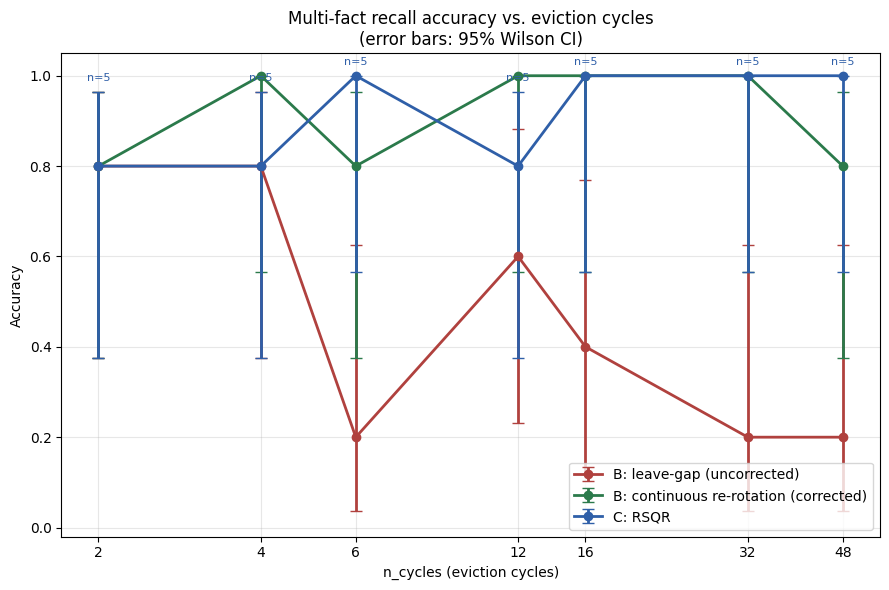

n_cycles |           B_corr |         B_uncorr |             RSQR | n_exercised
       2 |  80.0% [37.6,96.4] |  80.0% [37.6,96.4] |  80.0% [37.6,96.4] |           5
       4 | 100.0% [56.6,100.0] |  80.0% [37.6,96.4] |  80.0% [37.6,96.4] |           5
       6 |  80.0% [37.6,96.4] |  20.0% [ 3.6,62.4] | 100.0% [56.6,100.0] |           5
      12 | 100.0% [56.6,100.0] |  60.0% [23.1,88.2] |  80.0% [37.6,96.4] |           5
      16 | 100.0% [56.6,100.0] |  40.0% [11.8,76.9] | 100.0% [56.6,100.0] |           5
      32 | 100.0% [56.6,100.0] |  20.0% [ 3.6,62.4] | 100.0% [56.6,100.0] |           5
      48 |  80.0% [37.6,96.4] |  20.0% [ 3.6,62.4] | 100.0% [56.6,100.0] |           5


In [46]:
import json
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

LOG_PATH_BC = os.path.join(DRIVE_DIR, "per_trial_log_b_rsqr_test_seed_0.jsonl")

# --- Load ---
rows = []
with open(LOG_PATH_BC, "r") as f:
    for line in f:
        rows.append(json.loads(line))

cycle_values = sorted(set(r["n_cycles"] for r in rows))

def acc_with_ci(vals):
    """Wilson score interval — more honest than normal-approx CI at small n."""
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    k = int(vals.sum())
    p = k / n
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    return p, lo, hi, n

# --- Aggregate per n_cycles ---
stats = {"B_corrected": [], "B_uncorrected": [], "C_rsqr": []}
ns = {"B_corrected": [], "B_uncorrected": [], "C_rsqr": []}

for nc in cycle_values:
    rows_nc = [r for r in rows if r["n_cycles"] == nc]
    exercised_nc = [r for r in rows_nc if r.get("rsqr_path_exercised", True)]

    for key, source_rows in [
        ("B_corrected", rows_nc),
        ("B_uncorrected", rows_nc),
        ("C_rsqr", exercised_nc),  # only trials where RSQR mechanism actually fired
    ]:
        field = f"correct_{key}"
        p, lo, hi, n = acc_with_ci([r[field] for r in source_rows])
        stats[key].append((p, lo, hi))
        ns[key].append(n)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"B_corrected": "#2b7a4b", "B_uncorrected": "#b0413e", "C_rsqr": "#2f5fa8"}
labels = {
    "B_corrected": "B: continuous re-rotation (corrected)",
    "B_uncorrected": "B: leave-gap (uncorrected)",
    "C_rsqr": "C: RSQR",
}

for key in ["B_uncorrected", "B_corrected", "C_rsqr"]:
    ps = [s[0] for s in stats[key]]
    los = [s[1] for s in stats[key]]
    his = [s[2] for s in stats[key]]
    yerr = [[p - lo for p, lo in zip(ps, los)], [hi - p for p, hi in zip(ps, his)]]

    ax.errorbar(
        cycle_values, ps, yerr=yerr,
        label=labels[key], color=colors[key],
        marker="o", capsize=4, linewidth=2, markersize=6,
    )

# annotate n per point for RSQR (since exercised-n can differ from N_TRIALS_PER_K*len(SEEDS))
for x, (p, lo, hi), n in zip(cycle_values, stats["C_rsqr"], ns["C_rsqr"]):
    ax.annotate(f"n={n}", (x, hi), textcoords="offset points",
                xytext=(0, 8), fontsize=8, ha="center", color=colors["C_rsqr"])

ax.set_xlabel("n_cycles (eviction cycles)")
ax.set_ylabel("Accuracy")
ax.set_title("Multi-fact recall accuracy vs. eviction cycles\n(error bars: 95% Wilson CI)")
ax.set_xscale("log", base=2)
ax.set_xticks(cycle_values)
ax.set_xticklabels(cycle_values)
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rsqr_accuracy_comparison.png", dpi=150)
plt.show()

# --- Print summary table too, since the plot alone won't show n_exercised issues ---
print(f"{'n_cycles':>8} | {'B_corr':>16} | {'B_uncorr':>16} | {'RSQR':>16} | {'n_exercised':>11}")
for i, nc in enumerate(cycle_values):
    bc = stats["B_corrected"][i]
    bu = stats["B_uncorrected"][i]
    c = stats["C_rsqr"][i]
    print(f"{nc:>8} | {bc[0]*100:5.1f}% [{bc[1]*100:4.1f},{bc[2]*100:4.1f}] "
          f"| {bu[0]*100:5.1f}% [{bu[1]*100:4.1f},{bu[2]*100:4.1f}] "
          f"| {c[0]*100:5.1f}% [{c[1]*100:4.1f},{c[2]*100:4.1f}] "
          f"| {ns['C_rsqr'][i]:>11}")

In [ ]:
# --- Matched single-trial comparison: same stream, two implementations ---
# Goal: isolate whether the double-counting bug (flag-time promotion,
# no pending_raw staging) actually changes the model's answer on THIS
# specific trial, holding the token stream, seed, and magic_number fixed.

set_rsqr_log_level(logging.DEBUG)

rng = np.random.default_rng(0)  # same seed as seed0_cycles6_trial0
_stream, _fact_len, _magic = make_multi_cycle_stream_fast(
    rng, n_cycles=6, cycle_len=16, sink_size=len(SYSTEM_PREFIX_IDS)
)

print(f"magic_number={_magic}, stream_len={len(_stream)}, fact_len={_fact_len}")

# Run 1: CURRENTLY LOADED version (document 9 -- promote-at-flag-time,
# rank-compaction, no pending_raw staging). This is what produced the
# 0/1 result you just saw.
r_current = run_strategy_c_rsqr(
    _stream, fact_len=_fact_len, sink_size=len(SYSTEM_PREFIX_IDS),
    window_size=24, block_size=8, survivor_delta=4,
    trial_tag="MATCHED_current_flagtime",
)

print("\n" + "="*80)
print("CURRENT (flag-time promotion) RESULT:")
print(f"  correct={r_current['correct']}  logprob={r_current['answer_logprob']:.4f}")
print(f"  n_evictions={r_current['n_evictions']}  "
      f"n_survivors_retained={r_current['n_survivors_retained_at_query']}")
print("="*80 + "\n")

# NOTE: to run the staged version for comparison, redefine
# run_strategy_c_rsqr with the pending_raw/_promote_to_active version
# (document 6's fix) in a NEW cell first, then re-run this same stream
# through it -- do NOT overwrite _stream/rng state above, just call the
# new function on the same _stream/_fact_len/_magic you already have.

rsqr logger level set to DEBUG
magic_number=7, stream_len=133, fact_len=7
[INFO] [MATCHED_current_flagtime] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=4 stream_len=133 fact_len=7
[DEBUG] [MATCHED_current_flagtime] SINK step=0 global_pos=1 true_pos=1 sink_count=1
[DEBUG] [MATCHED_current_flagtime] SINK step=1 global_pos=2 true_pos=2 sink_count=2
[DEBUG] [MATCHED_current_flagtime] SINK step=2 global_pos=3 true_pos=3 sink_count=3
[DEBUG] [MATCHED_current_flagtime] SINK step=3 global_pos=4 true_pos=4 sink_count=4
[DEBUG] [MATCHED_current_flagtime] SINK step=4 global_pos=5 true_pos=5 sink_count=5
[DEBUG] [MATCHED_current_flagtime] SINK step=5 global_pos=6 true_pos=6 sink_count=6
[DEBUG] [MATCHED_current_flagtime] SINK step=6 global_pos=7 true_pos=7 sink_count=7
[DEBUG] [MATCHED_current_flagtime] SINK step=7 global_pos=8 true_pos=8 sink_count=8
[DEBUG] [MATCHED_current_flagtime] SINK step=8 global_pos=9 true_pos=9 sink_count=9
[DEBUG] [MATCHED_current_f

In [ ]:
# Cell A: generate ONE stream, print magic_number so you can visually
# confirm it matches across both runs
rng = np.random.default_rng(0)
_stream, _fact_len, _magic = make_multi_cycle_stream_fast(
    rng, n_cycles=6, cycle_len=16, sink_size=len(SYSTEM_PREFIX_IDS)
)
print(f"CAPTURED: magic_number={_magic}, stream_len={len(_stream)}, fact_len={_fact_len}")

CAPTURED: magic_number=7, stream_len=133, fact_len=7


In [ ]:
# Cell C: run OLD version against the captured stream
r_old = run_strategy_c_rsqr(_stream, fact_len=_fact_len, sink_size=len(SYSTEM_PREFIX_IDS),
                              window_size=24, block_size=8, survivor_delta=4,
                              trial_tag="OLD_flagtime")
print(f"OLD: correct={r_old['correct']} logprob={r_old['answer_logprob']:.4f}")

[INFO] [OLD_flagtime] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=4 stream_len=133 fact_len=7
[DEBUG] [OLD_flagtime] SINK step=0 global_pos=1 true_pos=1 sink_count=1
[DEBUG] [OLD_flagtime] SINK step=1 global_pos=2 true_pos=2 sink_count=2
[DEBUG] [OLD_flagtime] SINK step=2 global_pos=3 true_pos=3 sink_count=3
[DEBUG] [OLD_flagtime] SINK step=3 global_pos=4 true_pos=4 sink_count=4
[DEBUG] [OLD_flagtime] SINK step=4 global_pos=5 true_pos=5 sink_count=5
[DEBUG] [OLD_flagtime] SINK step=5 global_pos=6 true_pos=6 sink_count=6
[DEBUG] [OLD_flagtime] SINK step=6 global_pos=7 true_pos=7 sink_count=7
[DEBUG] [OLD_flagtime] SINK step=7 global_pos=8 true_pos=8 sink_count=8
[DEBUG] [OLD_flagtime] SINK step=8 global_pos=9 true_pos=9 sink_count=9
[DEBUG] [OLD_flagtime] SINK step=9 global_pos=10 true_pos=10 sink_count=10
[DEBUG] [OLD_flagtime] SINK step=10 global_pos=11 true_pos=11 sink_count=11
[DEBUG] [OLD_flagtime] SINK step=11 global_pos=12 true_pos=12 sink_co

In [ ]:
# Cell E: run STAGED version against the SAME captured stream
r_staged = run_strategy_c_rsqr(_stream, fact_len=_fact_len, sink_size=len(SYSTEM_PREFIX_IDS),
                                 window_size=24, block_size=8, survivor_delta=4,
                                 trial_tag="STAGED_pendingraw")
print(f"STAGED: correct={r_staged['correct']} logprob={r_staged['answer_logprob']:.4f}")
print(f"SAME STREAM CHECK: magic_number was {_magic} for both runs")

[INFO] [STAGED_pendingraw] run_strategy_c_rsqr START sink_size=24 window_size=24 block_size=8 survivor_delta=4 stream_len=133 fact_len=7
[INFO] [STAGED_pendingraw] FLAG(pending) step=34 global_pos=35 true_pos=35 -- captured raw K/V, NOT yet active (n_pending=1)
[INFO] [STAGED_pendingraw] FLAG(pending) step=38 global_pos=39 true_pos=39 -- captured raw K/V, NOT yet active (n_pending=2)
[INFO] [STAGED_pendingraw] FLAG(pending) step=42 global_pos=43 true_pos=43 -- captured raw K/V, NOT yet active (n_pending=3)
[INFO] [STAGED_pendingraw] FLAG(pending) step=46 global_pos=47 true_pos=47 -- captured raw K/V, NOT yet active (n_pending=4)
[INFO] [STAGED_pendingraw] FLAG(pending) step=50 global_pos=51 true_pos=51 -- captured raw K/V, NOT yet active (n_pending=5)
[INFO] [STAGED_pendingraw] FLAG(pending) step=54 global_pos=55 true_pos=55 -- captured raw K/V, NOT yet active (n_pending=6)
[INFO] [STAGED_pendingraw] FLAG(pending) step=58 global_pos=59 true_pos=59 -- captured raw K/V, NOT yet active (n